In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()

if ROOT.name == "notebooks":
    ROOT = ROOT.parent

REAL_RAW = ROOT / "data" / "raw" / "real" / "2026-07-19"
INTERIM = ROOT / "data" / "interim"
PROCESSED = ROOT / "data" / "processed"

print("Project root:", ROOT)
print("Real raw folder:", REAL_RAW)
print("Folder exists:", REAL_RAW.exists())

Project root: /Users/oliver/Downloads/video_rebuffering_risk_lab_fixed
Real raw folder: /Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/real/2026-07-19
Folder exists: True


In [2]:
files = sorted(REAL_RAW.glob("*"))

for path in files:
    if path.is_file():
        size_gb = path.stat().st_size / 1024**3
        print(f"{path.name}")
        print(f"  Size: {size_gb:.2f} GB")

client_buffer_2026-07-19T11_2026-07-20T11.csv
  Size: 8.06 GB
video_acked_2026-07-19T11_2026-07-20T11.csv
  Size: 1.12 GB
video_sent_2026-07-19T11_2026-07-20T11.csv
  Size: 1.74 GB


In [3]:
def find_one(prefix):
    matches = list(REAL_RAW.glob(f"{prefix}*"))

    if len(matches) == 0:
        raise FileNotFoundError(f"No file starts with: {prefix}")

    if len(matches) > 1:
        raise ValueError(
            f"Multiple files start with {prefix}: "
            f"{[p.name for p in matches]}"
        )

    return matches[0]


paths = {
    "client_buffer": find_one("client_buffer"),
    "video_acked": find_one("video_acked"),
    "video_sent": find_one("video_sent"),
}

for name, path in paths.items():
    print(name, "->", path.name)

client_buffer -> client_buffer_2026-07-19T11_2026-07-20T11.csv
video_acked -> video_acked_2026-07-19T11_2026-07-20T11.csv
video_sent -> video_sent_2026-07-19T11_2026-07-20T11.csv


what one row represents in each table;
	time (ns GMT)	session_id	index	expt_id	channel	event	buffer	cum_rebuf
0	1784461186791000000	eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=	2	2240	abc	init	0.000	0.000
	time (ns GMT)	session_id	index	expt_id	channel	video_ts	buffer	cum_rebuf
0	1784461187126000000	eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=	2	2240	abc	16423767360	2.002	0.000
	time (ns GMT)	session_id	index	expt_id	channel	video_ts	format	size	ssim_index	cwnd	in_flight	min_rtt	rtt	delivery_rate	buffer	cum_rebuf
0	1784461186794000000	eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=	2	2240	abc	16423767360	1280x720-20	780344	0.974398	1674	0	67043	98722	6175404	0.000	0.000
the correct stream and chunk identifiers;


timestamp meanings and ordering;
client_buffer: 1784461186791000000
video_sent:    1784461186794000000
video_acked:   1784461187126000000

missing values and duplicates;
no both

which variables exist at prediction time;


which variables could cause look-ahead leakage;
Variables that could cause look-ahead leakage are any values recorded after the prediction time, especially future video_acked information, future client_buffer reports, future buffer, and future cum_rebuf. When joining tables, only use rows whose timestamp is earlier than or equal to the video_sent prediction time.

whether the data can support a valid chunk-level, near-term rebuffer prediction problem.



In [4]:
samples = {}

for name, path in paths.items():
    df = pd.read_csv(path, nrows=1000)

    samples[name] = df

    print(f"\n===== {name} =====")
    print("Sample shape:", df.shape)
    display(df.head(5))


===== client_buffer =====
Sample shape: (1000, 8)


,time (ns GMT),session_id,index,expt_id,channel,event,buffer,cum_rebuf
0,1784461186791000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,init,0.000,0.000
1,1784461187249000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,startup,2.002,0.346
2,1784461187335000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,timer,1.897,0.346
3,1784461187562000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,timer,3.649,0.346
4,1784461187891000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,timer,5.401,0.346



===== video_acked =====
Sample shape: (1000, 8)


,time (ns GMT),session_id,index,expt_id,channel,video_ts,buffer,cum_rebuf
0,1784461187126000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16423767360,2.002,0.000
1,1784461187452000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16423947540,3.789,0.346
2,1784461187783000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16424127720,5.440,0.346
3,1784461188199000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16424307900,7.040,0.346
4,1784461188578000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16424488080,8.693,0.346



===== video_sent =====
Sample shape: (1000, 16)


,time (ns GMT),session_id,index,expt_id,channel,video_ts,format,size,ssim_index,cwnd,in_flight,min_rtt,rtt,delivery_rate,buffer,cum_rebuf
0,1784461186794000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16423767360,1280x720-20,780344,0.974398,1674,0,67043,98722,6175404,0.000,0.000
1,1784461187130000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16423947540,1280x720-20,673278,0.975522,612,0,67043,102152,54984,2.002,0.000
2,1784461187457000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16424127720,1280x720-20,742545,0.975965,602,0,67043,74561,3417132,3.789,0.346
3,1784461187787000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16424307900,1280x720-20,912239,0.975388,477,0,67043,77988,2586248,5.440,0.346
4,1784461188203000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,2240,abc,16424488080,1280x720-20,774798,0.973415,554,0,67043,88670,3247811,7.040,0.346


In [5]:
for name, df in samples.items():
    missing = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100
    })

    print(f"\n===== {name} =====")
    display(missing)


===== client_buffer =====


,missing_count,missing_percent
time (ns GMT),0,0.0
session_id,0,0.0
index,0,0.0
expt_id,0,0.0
channel,0,0.0
event,0,0.0
buffer,0,0.0
cum_rebuf,0,0.0



===== video_acked =====


,missing_count,missing_percent
time (ns GMT),0,0.0
session_id,0,0.0
index,0,0.0
expt_id,0,0.0
channel,0,0.0
video_ts,0,0.0
buffer,0,0.0
cum_rebuf,0,0.0



===== video_sent =====


,missing_count,missing_percent
time (ns GMT),0,0.0
session_id,0,0.0
index,0,0.0
expt_id,0,0.0
channel,0,0.0
video_ts,0,0.0
format,0,0.0
size,0,0.0
ssim_index,0,0.0
cwnd,0,0.0


In [6]:
chunk_keys = ["session_id", "index", "video_ts"]

for name in ["video_sent", "video_acked"]:
    df = samples[name]

    duplicate_chunks = df.duplicated(
        subset=chunk_keys,
        keep=False
    )

    print(f"\n{name}")
    print("Duplicated chunk identifiers:", duplicate_chunks.sum())

    if duplicate_chunks.any():
        display(
            df.loc[duplicate_chunks]
              .sort_values(chunk_keys)
              .head(10)
        )


video_sent
Duplicated chunk identifiers: 0

video_acked
Duplicated chunk identifiers: 0


inspect whether the three tables can be linked correctly.

In [7]:
for name, df in samples.items():
    print(f"\n===== {name} =====")
    print("Columns:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isna().sum())

    print("\nFull duplicate rows:")
    print(df.duplicated().sum())


===== client_buffer =====
Columns:
['time (ns GMT)', 'session_id', 'index', 'expt_id', 'channel', 'event', 'buffer', 'cum_rebuf']

Missing values:
time (ns GMT)    0
session_id       0
index            0
expt_id          0
channel          0
event            0
buffer           0
cum_rebuf        0
dtype: int64

Full duplicate rows:
0

===== video_acked =====
Columns:
['time (ns GMT)', 'session_id', 'index', 'expt_id', 'channel', 'video_ts', 'buffer', 'cum_rebuf']

Missing values:
time (ns GMT)    0
session_id       0
index            0
expt_id          0
channel          0
video_ts         0
buffer           0
cum_rebuf        0
dtype: int64

Full duplicate rows:
0

===== video_sent =====
Columns:
['time (ns GMT)', 'session_id', 'index', 'expt_id', 'channel', 'video_ts', 'format', 'size', 'ssim_index', 'cwnd', 'in_flight', 'min_rtt', 'rtt', 'delivery_rate', 'buffer', 'cum_rebuf']

Missing values:
time (ns GMT)    0
session_id       0
index            0
expt_id          0
channel      

In [8]:
chunk_keys = ["session_id", "index", "video_ts"]

for name in ["video_sent", "video_acked"]:
    df = samples[name]

    print(f"\n===== {name} =====")
    print(
        "Duplicate chunk keys:",
        df.duplicated(subset=chunk_keys).sum()
    )


===== video_sent =====
Duplicate chunk keys: 0

===== video_acked =====
Duplicate chunk keys: 0


Are there missing values?
no
Are there duplicate rows or duplicate chunk IDs?
no
Can video_sent and video_acked probably be joined using:
n this sample, session_id + index + video_ts appears to be a valid join key between video_sent and video_acked.

But this only proves it for the first 1,000 rows, not the full files.

In [9]:
chunk_keys = ["session_id", "index", "video_ts"]

sent_keys = samples["video_sent"][chunk_keys].drop_duplicates()
acked_keys = samples["video_acked"][chunk_keys].drop_duplicates()

matched = sent_keys.merge(
    acked_keys,
    on=chunk_keys,
    how="inner"
)

print("Unique sent chunks:", len(sent_keys))
print("Unique ACKed chunks:", len(acked_keys))
print("Matched chunks:", len(matched))

Unique sent chunks: 1000
Unique ACKed chunks: 1000
Matched chunks: 1000


In [10]:
chunk_keys = ["session_id", "index", "video_ts"]

sent = samples["video_sent"][
    chunk_keys + ["time (ns GMT)"]
].rename(columns={"time (ns GMT)": "sent_time"})

acked = samples["video_acked"][
    chunk_keys + ["time (ns GMT)"]
].rename(columns={"time (ns GMT)": "acked_time"})

joined = sent.merge(
    acked,
    on=chunk_keys,
    how="inner"
)

joined["ack_delay_ms"] = (
    joined["acked_time"] - joined["sent_time"]
) / 1_000_000

display(joined.head(5))

print("ACK before send:", (joined["ack_delay_ms"] < 0).sum())
print("ACK at same time:", (joined["ack_delay_ms"] == 0).sum())
print("Minimum delay:", joined["ack_delay_ms"].min(), "ms")
print("Median delay:", joined["ack_delay_ms"].median(), "ms")
print("Maximum delay:", joined["ack_delay_ms"].max(), "ms")

,session_id,index,video_ts,sent_time,acked_time,ack_delay_ms
0,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16423767360,1784461186794000000,1784461187126000000,332.0
1,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16423947540,1784461187130000000,1784461187452000000,322.0
2,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16424127720,1784461187457000000,1784461187783000000,326.0
3,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16424307900,1784461187787000000,1784461188199000000,412.0
4,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16424488080,1784461188203000000,1784461188578000000,375.0


ACK before send: 0
ACK at same time: 0
Minimum delay: 65.0 ms
Median delay: 150.0 ms
Maximum delay: 718.0 ms


When cumulative rebuffering increases, is the buffer usually close to zero?

In [11]:
buffer_df = samples["client_buffer"].copy()

buffer_df = buffer_df.sort_values(
    ["session_id", "index", "time (ns GMT)"]
)

buffer_df["cum_rebuf_change"] = (
    buffer_df
    .groupby(["session_id", "index"])["cum_rebuf"]
    .diff()
)

In [12]:
rebuffer_rows = buffer_df[
    buffer_df["cum_rebuf_change"] > 0
]

display(
    rebuffer_rows[
        [
            "time (ns GMT)",
            "event",
            "buffer",
            "cum_rebuf",
            "cum_rebuf_change"
        ]
    ].head(20)
)

print("Number of rebuffer increases:", len(rebuffer_rows))

,time (ns GMT),event,buffer,cum_rebuf,cum_rebuf_change
16,1784462795157000000,startup,2.002,0.191,0.191
1,1784461187249000000,startup,2.002,0.346,0.346


Number of rebuffer increases: 2


startup increase in cum_rebuf → ignore for this model
later increase in cum_rebuf   → count as rebuffer event
Initial model predicts mid-playback rebuffering only. Startup delay is excluded because it is a different user-experience problem.

In [13]:
playback_rebuffer_rows = buffer_df[
    (buffer_df["cum_rebuf_change"] > 0) &
    (buffer_df["event"] != "startup")
]

display(
    playback_rebuffer_rows[
        [
            "time (ns GMT)",
            "session_id",
            "index",
            "event",
            "buffer",
            "cum_rebuf",
            "cum_rebuf_change"
        ]
    ].head(20)
)

print(
    "Playback rebuffer increases:",
    len(playback_rebuffer_rows)
)

,time (ns GMT),session_id,index,event,buffer,cum_rebuf,cum_rebuf_change


Playback rebuffer increases: 0


So in the first 1,000 client_buffer rows, there are no mid-playback rebuffer events. The only increase came from startup delay.

This does not mean the full dataset has no playback rebuffering. It only means the first 1,000 rows do not contain any.

In [14]:
event_counts = (
    samples["client_buffer"]["event"]
    .value_counts()
)

print(event_counts)

event
timer      996
init         2
startup      2
Name: count, dtype: int64


user opens/selects video
→ player initializes
→ waits for enough buffer
→ playback starts
→ timer rows keep reporting buffer status

In [15]:
one_session = samples["client_buffer"]["session_id"].iloc[0]
one_index = samples["client_buffer"]["index"].iloc[0]

one_stream = (
    samples["client_buffer"]
    .query("session_id == @one_session and index == @one_index")
    .sort_values("time (ns GMT)")
)

display(
    one_stream[
        ["time (ns GMT)", "event", "buffer", "cum_rebuf"]
    ].head(30)
)

,time (ns GMT),event,buffer,cum_rebuf
0,1784461186791000000,init,0.000,0.000
1,1784461187249000000,startup,2.002,0.346
2,1784461187335000000,timer,1.897,0.346
3,1784461187562000000,timer,3.649,0.346
4,1784461187891000000,timer,5.401,0.346
5,1784461188123000000,timer,5.151,0.346
6,1784461188301000000,timer,6.902,0.346
7,1784461188582000000,timer,8.655,0.346
8,1784461189220000000,timer,12.462,0.346
9,1784461190205000000,timer,16.466,0.346


new chunk arrives → buffer jumps up
video keeps playing → buffer slowly decreases
another chunk arrives → buffer jumps up again

Can we see when chunks were sent during this same stream, and do buffer jumps happen near those send times?

In [16]:
sent_stream = samples["video_sent"][
    (samples["video_sent"]["session_id"] == one_session) &
    (samples["video_sent"]["index"] == one_index)
].sort_values("time (ns GMT)")

display(
    sent_stream[
        [
            "time (ns GMT)",
            "video_ts",
            "size",
            "format",
            "buffer",
            "delivery_rate",
            "rtt"
        ]
    ].head(20)
)

,time (ns GMT),video_ts,size,format,buffer,delivery_rate,rtt
0,1784461186794000000,16423767360,780344,1280x720-20,0.000,6175404,98722
1,1784461187130000000,16423947540,673278,1280x720-20,2.002,54984,102152
2,1784461187457000000,16424127720,742545,1280x720-20,3.789,3417132,74561
3,1784461187787000000,16424307900,912239,1280x720-20,5.440,2586248,77988
4,1784461188203000000,16424488080,774798,1280x720-20,7.040,3247811,88670
5,1784461188582000000,16424668260,502843,1280x720-20,8.693,2442866,78069
6,1784461188886000000,16424848440,505878,1280x720-20,10.460,3303639,92158
7,1784461189139000000,16425028620,537982,1280x720-20,12.462,3897873,73255
8,1784461189424000000,16425208800,498386,1280x720-20,14.464,2715744,75487


During this stream, chunks are delivered fast enough that the client buffer grows steadily, so rebuffer risk is low in this period.

In [17]:
stream_summary = (
    samples["client_buffer"]
    .groupby(["session_id", "index"])
    .agg(
        rows=("time (ns GMT)", "size"),
        start_time=("time (ns GMT)", "min"),
        end_time=("time (ns GMT)", "max"),
        max_buffer=("buffer", "max"),
        final_cum_rebuf=("cum_rebuf", "max")
    )
    .reset_index()
)

stream_summary["duration_s"] = (
    stream_summary["end_time"] - stream_summary["start_time"]
) / 1_000_000_000

display(stream_summary)

,session_id,index,rows,start_time,end_time,max_buffer,final_cum_rebuf,duration_s
0,1M2cFhrPXUzp1FNKwSGsLmeKe2onKZTJIllML1Z+ykk=,6,985,1784462794972000000,1784463040862000000,16.791,0.191,245.890
1,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,15,1784461186791000000,1784461195204000000,16.466,0.346,8.413


Does the longer stream ever reach very low buffer during normal playback?

In [18]:
long_stream = (
    stream_summary
    .sort_values("rows", ascending=False)
    .iloc[0]
)

long_session = long_stream["session_id"]
long_index = long_stream["index"]

long_buffer = samples["client_buffer"][
    (samples["client_buffer"]["session_id"] == long_session) &
    (samples["client_buffer"]["index"] == long_index) &
    (samples["client_buffer"]["event"] == "timer")
].copy()

print("Minimum timer buffer:", long_buffer["buffer"].min())
print("Rows with buffer below 1 second:")
print((long_buffer["buffer"] < 1).sum())

display(
    long_buffer.loc[
        long_buffer["buffer"] < 1,
        ["time (ns GMT)", "event", "buffer", "cum_rebuf"]
    ].head(20)
)

Minimum timer buffer: 1.918
Rows with buffer below 1 second:
0


,time (ns GMT),event,buffer,cum_rebuf


This sampled stream had a stable buffer and did not approach zero, so playback rebuffer risk was low.

Do playback rebuffer events exist once we inspect more data?

In [19]:
client_large = pd.read_csv(
    paths["client_buffer"],
    nrows=100_000
)

client_large = client_large.sort_values(
    ["session_id", "index", "time (ns GMT)"]
)

client_large["cum_rebuf_change"] = (
    client_large
    .groupby(["session_id", "index"])["cum_rebuf"]
    .diff()
)

playback_rebuffer_large = client_large[
    (client_large["cum_rebuf_change"] > 0) &
    (client_large["event"] != "startup")
]

print(
    "Playback rebuffer increases:",
    len(playback_rebuffer_large)
)

display(
    playback_rebuffer_large[
        [
            "time (ns GMT)",
            "session_id",
            "index",
            "event",
            "buffer",
            "cum_rebuf",
            "cum_rebuf_change"
        ]
    ].head(20)
)

Playback rebuffer increases: 0


,time (ns GMT),session_id,index,event,buffer,cum_rebuf,cum_rebuf_change


In the first 100,000 client_buffer rows, our current rule found no non-startup increase in cum_rebuf.

Are there other event types in these 100,000 rows besides timer, init, and startup?

In [20]:
print(client_large["event"].value_counts())

event
timer      99880
init          60
startup       60
Name: count, dtype: int64


Across these 60 sampled streams, cum_rebuf only increased at startup. No mid-playback rebuffer was detected.

Do any normal timer rows have a dangerously low buffer, even if rebuffering did not occur?

In [21]:
timer_rows = client_large[
    client_large["event"] == "timer"
]

print("Minimum timer buffer:", timer_rows["buffer"].min())
print("Rows below 1 second:", (timer_rows["buffer"] < 1).sum())
print("Rows below 0.5 seconds:", (timer_rows["buffer"] < 0.5).sum())
print("Rows equal to 0:", (timer_rows["buffer"] == 0).sum())

Minimum timer buffer: 1.61
Rows below 1 second: 0
Rows below 0.5 seconds: 0
Rows equal to 0: 0


The first 100,000 rows contain no low-buffer or playback-rebuffer cases. This sample may be too healthy for building a prediction model.

In [22]:
chunk_size = 500_000

rebuffer_results = []
last_cum_rebuf = {}

for chunk_number, chunk in enumerate(
    pd.read_csv(paths["client_buffer"], chunksize=chunk_size)
):
    chunk = chunk.sort_values(
        ["session_id", "index", "time (ns GMT)"]
    )

    changes = []

    for row in chunk.itertuples(index=False):
        stream_key = (row.session_id, row.index)
        current_value = row.cum_rebuf

        previous_value = last_cum_rebuf.get(stream_key)

        if previous_value is None:
            change = np.nan
        else:
            change = current_value - previous_value

        changes.append(change)
        last_cum_rebuf[stream_key] = current_value

    chunk["cum_rebuf_change"] = changes

    found = chunk[
        (chunk["cum_rebuf_change"] > 0) &
        (chunk["event"] != "startup")
    ]

    if len(found) > 0:
        rebuffer_results.append(found)

    print(
        f"Finished chunk {chunk_number + 1}, "
        f"rows scanned: {(chunk_number + 1) * chunk_size:,}, "
        f"events found: {sum(len(x) for x in rebuffer_results)}"
    )

Finished chunk 1, rows scanned: 500,000, events found: 217
Finished chunk 2, rows scanned: 1,000,000, events found: 237
Finished chunk 3, rows scanned: 1,500,000, events found: 629
Finished chunk 4, rows scanned: 2,000,000, events found: 1172
Finished chunk 5, rows scanned: 2,500,000, events found: 1245
Finished chunk 6, rows scanned: 3,000,000, events found: 1501
Finished chunk 7, rows scanned: 3,500,000, events found: 3528
Finished chunk 8, rows scanned: 4,000,000, events found: 3643
Finished chunk 9, rows scanned: 4,500,000, events found: 9743
Finished chunk 10, rows scanned: 5,000,000, events found: 9974
Finished chunk 11, rows scanned: 5,500,000, events found: 10280
Finished chunk 12, rows scanned: 6,000,000, events found: 10455
Finished chunk 13, rows scanned: 6,500,000, events found: 10469
Finished chunk 14, rows scanned: 7,000,000, events found: 10470
Finished chunk 15, rows scanned: 7,500,000, events found: 13940
Finished chunk 16, rows scanned: 8,000,000, events found: 14836


In [23]:
if rebuffer_results:
    playback_rebuffers = pd.concat(
        rebuffer_results,
        ignore_index=True
    )

    print(
        "Total playback rebuffer increases:",
        len(playback_rebuffers)
    )

    display(
        playback_rebuffers[
            [
                "time (ns GMT)",
                "session_id",
                "index",
                "event",
                "buffer",
                "cum_rebuf",
                "cum_rebuf_change"
            ]
        ].head(20)
    )
else:
    playback_rebuffers = pd.DataFrame()
    print("No playback rebuffer increases found.")

Total playback rebuffer increases: 68254


,time (ns GMT),session_id,index,event,buffer,cum_rebuf,cum_rebuf_change
0,1784472128562000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,timer,0.018,0.217,0.047
1,1784472128790000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,play,0.613,0.418,0.201
2,1784472130551000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,timer,0.025,0.473,0.055
3,1784472130802000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,timer,0.000,0.729,0.256
4,1784472131042000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,timer,0.000,0.966,0.237
5,1784472131290000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,timer,0.000,1.217,0.251
6,1784472131446000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,play,1.129,1.317,0.100
7,1784475678288000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,play,1.862,1.465,0.148
8,1784476358840000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,timer,0.000,1.558,0.093
9,1784476359096000000,Ftd9ukvSITLlbrxmxgismmxL9IxOzeKL2jXJ72w5qA8=,8,timer,0.000,1.814,0.256


In [24]:
# Cell B: combine results
if rebuffer_results:
    playback_rebuffers = pd.concat(
        rebuffer_results,
        ignore_index=True
    )
else:
    playback_rebuffers = pd.DataFrame()

In [25]:
# Cell C: turn rebuffer rows into separate freeze episodes

playback_rebuffers = playback_rebuffers.sort_values(
    ["session_id", "index", "time (ns GMT)"]
).copy()

playback_rebuffers["previous_time"] = (
    playback_rebuffers
    .groupby(["session_id", "index"])["time (ns GMT)"]
    .shift()
)

playback_rebuffers["gap_s"] = (
    playback_rebuffers["time (ns GMT)"]
    - playback_rebuffers["previous_time"]
) / 1_000_000_000

playback_rebuffers["new_episode"] = (
    playback_rebuffers["gap_s"].isna()
    | (playback_rebuffers["gap_s"] > 1)
)

playback_rebuffers["episode_id"] = (
    playback_rebuffers
    .groupby(["session_id", "index"])["new_episode"]
    .cumsum()
)

episode_summary = (
    playback_rebuffers
    .groupby(["session_id", "index", "episode_id"])
    .agg(
        start_time=("time (ns GMT)", "min"),
        end_time=("time (ns GMT)", "max"),
        number_of_reports=("time (ns GMT)", "size"),
        rebuffer_duration_s=("cum_rebuf_change", "sum"),
        minimum_buffer_s=("buffer", "min"),
        maximum_buffer_s=("buffer", "max")
    )
    .reset_index()
)

episode_summary["logged_span_s"] = (
    episode_summary["end_time"]
    - episode_summary["start_time"]
) / 1_000_000_000

print("Separate playback freeze episodes:", len(episode_summary))

display(episode_summary.head(20))

Separate playback freeze episodes: 6520


,session_id,index,episode_id,start_time,end_time,number_of_reports,rebuffer_duration_s,minimum_buffer_s,maximum_buffer_s,logged_span_s
0,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,1,1784516153116000002,1784516153490000000,12,2.950,0.000,0.000,3.740000e-01
1,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,2,1784516154563000000,1784516154968000000,12,2.999,0.000,0.000,4.050000e-01
2,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,3,1784516172558000000,1784516174346000004,51,12.501,0.000,1.943,1.788000e+00
3,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,4,1784516175787000000,1784516175787000000,1,0.050,1.974,1.974,0.000000e+00
4,+TDVX7kkUCO1EpN3Q7qOzm4f6IHhOanq61b23DdHOrU=,0,1,1784467611901000000,1784467612031000000,2,0.149,0.000,2.002,1.300000e-01
5,+cqMzDiexKgabKRQ8MOIreQ6E1xQzDAjl9QPDvJA6YE=,2,1,1784508676382000023,1784508678613000000,30,7.399,0.000,1.420,2.231000e+00
6,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,1,1784511842052000005,1784511844730000000,39,9.650,0.000,0.162,2.678000e+00
7,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,2,1784512075777000014,1784512079335000000,18,4.099,0.000,1.989,3.558000e+00
8,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,3,1784512135487000000,1784512137130000000,8,1.750,0.000,0.444,1.643000e+00
9,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,4,1784512147734000000,1784512148732000000,5,1.051,0.000,0.025,9.980000e-01


In [26]:
print(playback_rebuffers["time (ns GMT)"].dtype)

int64


In [27]:
print(playback_rebuffers["time (ns GMT)"].head())
print(playback_rebuffers["time (ns GMT)"].tail())

19726    1784516153116000002
19727    1784516153116000003
19728    1784516153116000004
19729    1784516153116000005
19730    1784516153116000006
Name: time (ns GMT), dtype: int64
60757    1784490160709000000
60758    1784490161222000001
60759    1784490161232000000
60760    1784490161469000000
60761    1784490161724000000
Name: time (ns GMT), dtype: int64


In [28]:
all_streams = set()
chunk_size = 500_000

episode_rows = []
last_cum_rebuf = {}
last_rebuffer_state = {}
episode_number = {}

for chunk_number, chunk in enumerate(
    pd.read_csv(paths["client_buffer"], chunksize=chunk_size)
):
    chunk = chunk.sort_values(
        ["session_id", "index", "time (ns GMT)"]
    ).copy()
    all_streams.update(
    zip(chunk["session_id"], chunk["index"])
    )
    changes = []
    states = []
    episode_ids = []

    for row in chunk.itertuples(index=False):
        stream_key = (row.session_id, row.index)

        previous_cum = last_cum_rebuf.get(stream_key)

        if previous_cum is None:
            change = 0
        else:
            change = row.cum_rebuf - previous_cum

        is_rebuffering = (
            change > 0 and row.event != "startup"
        )

        previous_state = last_rebuffer_state.get(
            stream_key,
            False
        )

        # Start a new episode
        if is_rebuffering and not previous_state:
            episode_number[stream_key] = (
                episode_number.get(stream_key, 0) + 1
            )

        changes.append(change)
        states.append(is_rebuffering)
        episode_ids.append(
            episode_number.get(stream_key, 0)
        )

        last_cum_rebuf[stream_key] = row.cum_rebuf
        last_rebuffer_state[stream_key] = is_rebuffering

    chunk["cum_rebuf_change"] = changes
    chunk["is_rebuffering"] = states
    chunk["episode_id"] = episode_ids

    found = chunk[chunk["is_rebuffering"]].copy()

    if not found.empty:
        episode_rows.append(found)

    print(
        f"Finished chunk {chunk_number + 1}, "
        f"rows scanned: {(chunk_number + 1) * chunk_size:,}"
    )

Finished chunk 1, rows scanned: 500,000
Finished chunk 2, rows scanned: 1,000,000
Finished chunk 3, rows scanned: 1,500,000
Finished chunk 4, rows scanned: 2,000,000
Finished chunk 5, rows scanned: 2,500,000
Finished chunk 6, rows scanned: 3,000,000
Finished chunk 7, rows scanned: 3,500,000
Finished chunk 8, rows scanned: 4,000,000
Finished chunk 9, rows scanned: 4,500,000
Finished chunk 10, rows scanned: 5,000,000
Finished chunk 11, rows scanned: 5,500,000
Finished chunk 12, rows scanned: 6,000,000
Finished chunk 13, rows scanned: 6,500,000
Finished chunk 14, rows scanned: 7,000,000
Finished chunk 15, rows scanned: 7,500,000
Finished chunk 16, rows scanned: 8,000,000
Finished chunk 17, rows scanned: 8,500,000
Finished chunk 18, rows scanned: 9,000,000
Finished chunk 19, rows scanned: 9,500,000
Finished chunk 20, rows scanned: 10,000,000
Finished chunk 21, rows scanned: 10,500,000
Finished chunk 22, rows scanned: 11,000,000
Finished chunk 23, rows scanned: 11,500,000
Finished chunk 24,

In [29]:
full_rebuffer_rows = pd.concat(
    episode_rows,
    ignore_index=True
)

episode_summary_state = (
    full_rebuffer_rows
    .groupby(["session_id", "index", "episode_id"])
    .agg(
        start_time=("time (ns GMT)", "min"),
        end_time=("time (ns GMT)", "max"),
        rebuffer_duration_s=("cum_rebuf_change", "sum"),
        minimum_buffer_s=("buffer", "min"),
        maximum_buffer_s=("buffer", "max"),
        number_of_reports=("time (ns GMT)", "size")
    )
    .reset_index()
)

print(
    "Separate playback freeze episodes:",
    len(episode_summary_state)
)

display(episode_summary_state.head(20))

Separate playback freeze episodes: 5541


,session_id,index,episode_id,start_time,end_time,rebuffer_duration_s,minimum_buffer_s,maximum_buffer_s,number_of_reports
0,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,1,1784516153116000002,1784516154968000000,5.949,0.000,0.000,24
1,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,2,1784516172558000000,1784516172558000000,0.049,1.943,1.943,1
2,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,3,1784516173482000000,1784516174346000004,12.452,0.000,0.000,50
3,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,4,1784516175787000000,1784516175787000000,0.050,1.974,1.974,1
4,+TDVX7kkUCO1EpN3Q7qOzm4f6IHhOanq61b23DdHOrU=,0,1,1784467611901000000,1784467612031000000,0.149,0.000,2.002,2
5,+cqMzDiexKgabKRQ8MOIreQ6E1xQzDAjl9QPDvJA6YE=,2,1,1784508676382000023,1784508678613000000,7.399,0.000,1.420,30
6,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,1,1784511842052000005,1784511844730000000,9.650,0.000,0.162,39
7,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,2,1784512075777000014,1784512079335000000,4.099,0.000,1.989,18
8,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,3,1784512135487000000,1784512137130000000,1.750,0.000,0.444,8
9,/VGct5Z7eTWYYSjZSRbk2yEzIUwlAup0Uy83Y//q6yo=,0,4,1784512147734000000,1784512160081000000,12.350,0.000,1.081,51


What is the distribution of freeze durations, and how many episodes are extremely short?

In [30]:
print(
    episode_summary_state["rebuffer_duration_s"]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
)

print(
    "\nEpisodes shorter than 0.1 seconds:",
    (episode_summary_state["rebuffer_duration_s"] < 0.1).sum()
)

print(
    "Episodes shorter than 0.25 seconds:",
    (episode_summary_state["rebuffer_duration_s"] < 0.25).sum()
)

print(
    "Episodes with minimum buffer equal to 0:",
    (episode_summary_state["minimum_buffer_s"] == 0).sum()
)

count    5541.000000
mean        3.266377
std         6.871017
min         0.027000
1%          0.049000
5%          0.100000
25%         0.452000
50%         1.151000
75%         3.297000
95%        12.699000
99%        29.837800
max       126.772000
Name: rebuffer_duration_s, dtype: float64

Episodes shorter than 0.1 seconds: 268
Episodes shorter than 0.25 seconds: 790
Episodes with minimum buffer equal to 0: 3953


Typical freeze is about 1.15 seconds (median).
Most freezes are short to medium.
A small number are very long, up to 126.8 seconds.
Only 268 / 5,541 ≈ 4.8% are shorter than 0.1 seconds.
790 / 5,541 ≈ 14.3% are shorter than 0.25 seconds.
About 71.3% of episodes reached buffer exactly 0.

Playback rebuffer episode:
cum_rebuf starts increasing after startup
→ continues increasing
→ stops increasing

How many separate streams experienced at least one playback freeze, and how many episodes did each stream have?

In [31]:
stream_freeze_summary = (
    episode_summary_state
    .groupby(["session_id", "index"])
    .agg(
        freeze_episodes=("episode_id", "count"),
        total_rebuffer_s=("rebuffer_duration_s", "sum"),
        longest_rebuffer_s=("rebuffer_duration_s", "max")
    )
    .reset_index()
)

print(
    "Streams with at least one playback freeze:",
    len(stream_freeze_summary)
)

display(
    stream_freeze_summary
    .sort_values("freeze_episodes", ascending=False)
    .head(20)
)

Streams with at least one playback freeze: 536


,session_id,index,freeze_episodes,total_rebuffer_s,longest_rebuffer_s
485,vf8sEl+uWrdO3Wzf2vwhBlEu1dL0IjFyLFeUH/9f3m0=,0,243,452.264,23.050
281,UKdcz6CZAs8fgWOq9+8olhGXa0iaMvdi+YqmHO6WdHw=,22,233,289.233,5.572
184,K4YDiLzjIxHttrdpO7FFc/BVB7dob0bvTsEpP5snfNc=,8,231,509.467,11.199
458,ru4QoZ0yBpIFh5m/aDpx+fzkXkF2VBz4klZiZXqwwcQ=,0,228,518.450,10.798
357,dmbOMTCzgPxfvM2sbM6NNVePFScKsPEFV9HiPYIgBqA=,1,195,296.013,16.106
388,j1PdKl1PaLJfr9nba5PNZREs8yNwvNGxapTIFX+does=,0,182,468.421,26.136
135,F+e+VBB3zTQJLXm5QpbThltn0jYd11Fb/DtnpepFvMI=,0,176,298.304,13.865
486,vf8sEl+uWrdO3Wzf2vwhBlEu1dL0IjFyLFeUH/9f3m0=,1,171,189.896,9.849
411,mEUjuFkRAf8WO9gFf33Gvdl4iC82ZsOOpZQYWyItw4M=,1,170,81.308,2.650
164,IkRg/7vL2GrwzBe3N7i16QNaPhYfTi9jUwgeynTiKj8=,0,161,299.978,19.537


In [32]:
print(
    "Streams with at least one playback freeze:",
    len(stream_freeze_summary)
)

Streams with at least one playback freeze: 536


What percentage of all streams experienced at least one playback freeze?

In [33]:
total_streams = len(all_streams)
affected_streams = len(stream_freeze_summary)

freeze_stream_percent = (
    affected_streams / total_streams * 100
)

print("Total streams:", total_streams)
print("Streams with playback freeze:", affected_streams)
print(f"Percentage with freeze: {freeze_stream_percent:.2f}%")

Total streams: 34852
Streams with playback freeze: 536
Percentage with freeze: 1.54%


Total streams: 34,852
Streams with at least one playback freeze: 536
Freeze rate: 1.54%
No-freeze rate: 98.46%

So playback freezing is rare and imbalanced.

That matters because later, a model could predict “no freeze” for every stream and still look highly accurate. Therefore, accuracy will not be a good main metric. We will need metrics like:

Recall: how many real freeze cases we catch
Precision: how many predicted freezes are actually freezes
PR-AUC: overall performance for rare positive events

At the chunk level, how many video_sent rows occur shortly before a freeze?

In [34]:
freeze_starts = (
    episode_summary_state[
        ["session_id", "index", "start_time"]
    ]
    .rename(columns={"start_time": "freeze_start_time"})
)

display(freeze_starts.head())

,session_id,index,freeze_start_time
0,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,1784516153116000002
1,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,1784516172558000000
2,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,1784516173482000000
3,+FKTWDKPkiqr0t+qqJ/HOLt/Q8ioHu2aBbtLSGIGXxU=,0,1784516175787000000
4,+TDVX7kkUCO1EpN3Q7qOzm4f6IHhOanq61b23DdHOrU=,0,1784467611901000000


In [35]:
# Prediction horizon: 5 seconds
horizon_ns = 5 * 1_000_000_000

# Prepare freeze start table
freeze_lookup = freeze_starts.copy()

freeze_lookup["freeze_start_time"] = (
    freeze_lookup["freeze_start_time"].astype("int64")
)

freeze_lookup = freeze_lookup.sort_values(
    ["freeze_start_time", "session_id", "index"]
)

chunk_size = 500_000

total_sent_rows = 0
positive_rows = 0
negative_rows = 0
positive_examples = []

for chunk_number, sent_chunk in enumerate(
    pd.read_csv(
        paths["video_sent"],
        chunksize=chunk_size
    )
):
    # Rename time to make its meaning clear
    sent_chunk = sent_chunk.rename(
        columns={"time (ns GMT)": "sent_time"}
    )

    sent_chunk["sent_time"] = (
        sent_chunk["sent_time"].astype("int64")
    )

    # merge_asof requires time ordering
    sent_chunk = sent_chunk.sort_values(
        ["sent_time", "session_id", "index"]
    )

    # Find the next freeze in the same stream
    labelled_chunk = pd.merge_asof(
        sent_chunk,
        freeze_lookup,
        left_on="sent_time",
        right_on="freeze_start_time",
        by=["session_id", "index"],
        direction="forward",
        tolerance=horizon_ns
    )

    # 1 if a freeze begins within the next 5 seconds
    labelled_chunk["target_5s"] = (
        labelled_chunk["freeze_start_time"].notna().astype(int)
    )

    # Time from chunk send to freeze start
    labelled_chunk["seconds_until_freeze"] = (
        labelled_chunk["freeze_start_time"]
        - labelled_chunk["sent_time"]
    ) / 1_000_000_000

    chunk_positive = labelled_chunk["target_5s"].sum()
    chunk_rows = len(labelled_chunk)

    total_sent_rows += chunk_rows
    positive_rows += chunk_positive
    negative_rows += chunk_rows - chunk_positive

    # Keep a few positive examples for inspection
    examples = labelled_chunk[
        labelled_chunk["target_5s"] == 1
    ].head(5)

    if not examples.empty and len(positive_examples) < 5:
        positive_examples.append(examples)

    print(
        f"Finished chunk {chunk_number + 1} | "
        f"Rows processed: {total_sent_rows:,} | "
        f"Positive labels: {positive_rows:,}"
    )

Finished chunk 1 | Rows processed: 500,000 | Positive labels: 677
Finished chunk 2 | Rows processed: 1,000,000 | Positive labels: 1,625
Finished chunk 3 | Rows processed: 1,500,000 | Positive labels: 1,689
Finished chunk 4 | Rows processed: 2,000,000 | Positive labels: 1,871
Finished chunk 5 | Rows processed: 2,500,000 | Positive labels: 1,895
Finished chunk 6 | Rows processed: 3,000,000 | Positive labels: 1,924
Finished chunk 7 | Rows processed: 3,500,000 | Positive labels: 1,982
Finished chunk 8 | Rows processed: 4,000,000 | Positive labels: 1,993
Finished chunk 9 | Rows processed: 4,500,000 | Positive labels: 2,012
Finished chunk 10 | Rows processed: 5,000,000 | Positive labels: 2,812
Finished chunk 11 | Rows processed: 5,500,000 | Positive labels: 2,853
Finished chunk 12 | Rows processed: 6,000,000 | Positive labels: 3,035
Finished chunk 13 | Rows processed: 6,500,000 | Positive labels: 3,578
Finished chunk 14 | Rows processed: 7,000,000 | Positive labels: 3,694
Finished chunk 15 |

In [36]:
positive_rate = positive_rows / total_sent_rows * 100

print("Total video_sent rows:", total_sent_rows)
print("Positive target_5s rows:", positive_rows)
print("Negative target_5s rows:", negative_rows)
print(f"Positive label rate: {positive_rate:.4f}%")

Total video_sent rows: 11900686
Positive target_5s rows: 5483
Negative target_5s rows: 11895203
Positive label rate: 0.0461%


In [37]:
if positive_examples:
    positive_example_df = pd.concat(
        positive_examples,
        ignore_index=True
    )

    display(
        positive_example_df[
            [
                "session_id",
                "index",
                "video_ts",
                "sent_time",
                "freeze_start_time",
                "seconds_until_freeze",
                "buffer",
                "rtt",
                "delivery_rate",
                "target_5s"
            ]
        ].head(20)
    )
else:
    print("No positive examples found.")

,session_id,index,video_ts,sent_time,freeze_start_time,seconds_until_freeze,buffer,rtt,delivery_rate,target_5s
0,raX170SYGeEp5HuJvod8o7mNXDglg7vkiX8nWw7esVs=,0,16229533320,1784459032681000000,1.784459e+18,0.941,2.002,100762,16240,1
1,raX170SYGeEp5HuJvod8o7mNXDglg7vkiX8nWw7esVs=,1,16243227000,1784459199283000000,1.784459e+18,4.160,0.465,125971,54729,1
2,raX170SYGeEp5HuJvod8o7mNXDglg7vkiX8nWw7esVs=,1,16243407180,1784459204103000000,1.784459e+18,1.028,0.943,236053,44285,1
3,raX170SYGeEp5HuJvod8o7mNXDglg7vkiX8nWw7esVs=,1,16272776520,1784459527161000000,1.784460e+18,4.492,4.408,186466,27836,1
4,raX170SYGeEp5HuJvod8o7mNXDglg7vkiX8nWw7esVs=,1,16273136880,1784459540285000000,1.784460e+18,2.407,1.542,170042,24133,1
5,T06lXRvCe9FBZR7sDPIMRs5ZAFsxKjhLyFBi3fwaQso=,1,16959082140,1784467131267000000,1.784467e+18,0.158,2.764,203555,186912,1
6,CQ+hIMlnJcu9rsujWZm6S3yhfTuC3+9d907IyLBLaz4=,1,17118181080,1784468916261000000,1.784469e+18,4.997,0.000,643816,12619,1
7,CQ+hIMlnJcu9rsujWZm6S3yhfTuC3+9d907IyLBLaz4=,1,17118361260,1784468920262000000,1.784469e+18,0.996,1.074,755018,14010,1
8,CQ+hIMlnJcu9rsujWZm6S3yhfTuC3+9d907IyLBLaz4=,1,17118541440,1784468924273000000,1.784469e+18,2.991,1.302,691143,11116,1
9,CQ+hIMlnJcu9rsujWZm6S3yhfTuC3+9d907IyLBLaz4=,1,17118721620,1784468928268000000,1.784469e+18,0.999,1.218,693491,9804,1


In [38]:
positive_example_df["freeze_start_time"] = (
    positive_example_df["freeze_start_time"]
    .astype("Int64")
)

In [39]:
# Give every freeze episode a unique ID
freeze_lookup = (
    episode_summary_state[
        ["session_id", "index", "episode_id", "start_time"]
    ]
    .rename(columns={"start_time": "freeze_start_time"})
    .copy()
)

freeze_lookup["freeze_id"] = np.arange(len(freeze_lookup))

freeze_lookup = freeze_lookup.sort_values(
    "freeze_start_time"
)

# Five-second prediction window
horizon_ns = 5 * 1_000_000_000

# Store freeze episodes that have at least one sent row
covered_freeze_ids = set()

chunk_size = 500_000

for chunk_number, sent_chunk in enumerate(
    pd.read_csv(
        paths["video_sent"],
        chunksize=chunk_size
    )
):
    sent_chunk = sent_chunk.rename(
        columns={"time (ns GMT)": "sent_time"}
    )

    sent_chunk = sent_chunk.sort_values("sent_time")

    matched = pd.merge_asof(
        sent_chunk,
        freeze_lookup,
        left_on="sent_time",
        right_on="freeze_start_time",
        by=["session_id", "index"],
        direction="forward",
        tolerance=horizon_ns
    )

    matched_ids = matched["freeze_id"].dropna().astype(int)

    covered_freeze_ids.update(matched_ids.tolist())

    print(
        f"Finished chunk {chunk_number + 1} | "
        f"Covered freeze episodes: {len(covered_freeze_ids):,}"
    )

Finished chunk 1 | Covered freeze episodes: 384
Finished chunk 2 | Covered freeze episodes: 1,162
Finished chunk 3 | Covered freeze episodes: 1,214
Finished chunk 4 | Covered freeze episodes: 1,353
Finished chunk 5 | Covered freeze episodes: 1,372
Finished chunk 6 | Covered freeze episodes: 1,396
Finished chunk 7 | Covered freeze episodes: 1,449
Finished chunk 8 | Covered freeze episodes: 1,459
Finished chunk 9 | Covered freeze episodes: 1,475
Finished chunk 10 | Covered freeze episodes: 2,137
Finished chunk 11 | Covered freeze episodes: 2,171
Finished chunk 12 | Covered freeze episodes: 2,323
Finished chunk 13 | Covered freeze episodes: 2,754
Finished chunk 14 | Covered freeze episodes: 2,844
Finished chunk 15 | Covered freeze episodes: 2,942
Finished chunk 16 | Covered freeze episodes: 3,078
Finished chunk 17 | Covered freeze episodes: 3,332
Finished chunk 18 | Covered freeze episodes: 3,379
Finished chunk 19 | Covered freeze episodes: 3,393
Finished chunk 20 | Covered freeze episode

In [40]:
total_freeze_episodes = len(freeze_lookup)
covered_freeze_episodes = len(covered_freeze_ids)

uncovered_freeze_episodes = (
    total_freeze_episodes - covered_freeze_episodes
)

coverage_rate = (
    covered_freeze_episodes
    / total_freeze_episodes
    * 100
)

print("Total freeze episodes:", total_freeze_episodes)
print(
    "Freeze episodes with a sent row in previous 5 seconds:",
    covered_freeze_episodes
)
print(
    "Freeze episodes without a sent row in previous 5 seconds:",
    uncovered_freeze_episodes
)
print(f"Five-second episode coverage: {coverage_rate:.2f}%")

Total freeze episodes: 5541
Freeze episodes with a sent row in previous 5 seconds: 4207
Freeze episodes without a sent row in previous 5 seconds: 1334
Five-second episode coverage: 75.92%


Why were 24.08% of freeze episodes not covered by a sent event in the previous five seconds?

Are chunks sent within five seconds before a freeze delivered more slowly than normal chunks?

In [41]:
# Columns needed from each file
sent_columns = [
    "time (ns GMT)",
    "session_id",
    "index",
    "video_ts",
    "size",
    "buffer",
    "rtt",
    "delivery_rate"
]

acked_columns = [
    "time (ns GMT)",
    "session_id",
    "index",
    "video_ts"
]

chunk_keys = ["session_id", "index", "video_ts"]
horizon_ns = 5 * 1_000_000_000
chunk_size = 500_000

In [42]:
acked_full = pd.read_csv(
    paths["video_acked"],
    usecols=acked_columns
)

acked_full = acked_full.rename(
    columns={"time (ns GMT)": "acked_time"}
)

acked_full["acked_time"] = (
    acked_full["acked_time"].astype("int64")
)

print("ACK rows loaded:", len(acked_full))
display(acked_full.head())

ACK rows loaded: 11888562


,acked_time,session_id,index,video_ts
0,1784461187126000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16423767360
1,1784461187452000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16423947540
2,1784461187783000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16424127720
3,1784461188199000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16424307900
4,1784461188578000000,eMS9pWUdc8E/0bTtn/MWzYRSEwojcjZ8DMu+RveNx0g=,2,16424488080


In [43]:
freeze_lookup = freeze_starts.copy()

freeze_lookup["freeze_start_time"] = (
    freeze_lookup["freeze_start_time"].astype("int64")
)

freeze_lookup = freeze_lookup.sort_values(
    ["freeze_start_time", "session_id", "index"]
)

In [44]:
comparison_results = []

for chunk_number, sent_chunk in enumerate(
    pd.read_csv(
        paths["video_sent"],
        usecols=sent_columns,
        chunksize=chunk_size
    )
):
    sent_chunk = sent_chunk.rename(
        columns={"time (ns GMT)": "sent_time"}
    )

    sent_chunk["sent_time"] = (
        sent_chunk["sent_time"].astype("int64")
    )

    # Find whether the next freeze starts within 5 seconds
    sent_chunk = sent_chunk.sort_values(
        ["sent_time", "session_id", "index"]
    )

    labelled = pd.merge_asof(
        sent_chunk,
        freeze_lookup,
        left_on="sent_time",
        right_on="freeze_start_time",
        by=["session_id", "index"],
        direction="forward",
        tolerance=horizon_ns
    )

    labelled["target_5s"] = (
        labelled["freeze_start_time"]
        .notna()
        .astype(int)
    )

    # Match each sent chunk with its ACK
    labelled = labelled.merge(
        acked_full,
        on=chunk_keys,
        how="left"
    )

    labelled["ack_delay_ms"] = (
        labelled["acked_time"]
        - labelled["sent_time"]
    ) / 1_000_000

    labelled["ack_missing"] = (
        labelled["acked_time"].isna()
    )

    # Keep only the columns needed for comparison
    comparison_results.append(
    labelled[
        [
            "target_5s",
            "sent_time",
            "freeze_start_time",
            "acked_time",
            "ack_delay_ms",
            "ack_missing",
            "buffer",
            "rtt",
            "delivery_rate",
            "size"
        ]
    ]
    )

    print(
        f"Finished chunk {chunk_number + 1} | "
        f"Rows processed: "
        f"{sum(len(x) for x in comparison_results):,}"
    )

Finished chunk 1 | Rows processed: 500,000
Finished chunk 2 | Rows processed: 1,000,000
Finished chunk 3 | Rows processed: 1,500,000
Finished chunk 4 | Rows processed: 2,000,000
Finished chunk 5 | Rows processed: 2,500,000
Finished chunk 6 | Rows processed: 3,000,000
Finished chunk 7 | Rows processed: 3,500,000
Finished chunk 8 | Rows processed: 4,000,000
Finished chunk 9 | Rows processed: 4,500,000
Finished chunk 10 | Rows processed: 5,000,000
Finished chunk 11 | Rows processed: 5,500,000
Finished chunk 12 | Rows processed: 6,000,000
Finished chunk 13 | Rows processed: 6,500,000
Finished chunk 14 | Rows processed: 7,000,000
Finished chunk 15 | Rows processed: 7,500,000
Finished chunk 16 | Rows processed: 8,000,000
Finished chunk 17 | Rows processed: 8,500,000
Finished chunk 18 | Rows processed: 9,000,000
Finished chunk 19 | Rows processed: 9,500,000
Finished chunk 20 | Rows processed: 10,000,000
Finished chunk 21 | Rows processed: 10,500,000
Finished chunk 22 | Rows processed: 11,000,

In [45]:
comparison_df = pd.concat(
    comparison_results,
    ignore_index=True
)

print("Total rows:", len(comparison_df))
display(comparison_df.head())

Total rows: 11900686


,target_5s,sent_time,freeze_start_time,acked_time,ack_delay_ms,ack_missing,buffer,rtt,delivery_rate,size
0,0,1784458800155000000,NaN,1.784459e+18,110.999808,False,14.881,81788,10097972,331332
1,0,1784458800349000000,NaN,1.784459e+18,12.999936,False,14.819,4223,60378674,511720
2,0,1784458800391000000,NaN,1.784459e+18,167.000064,False,14.773,2524,120666666,511720
3,0,1784458801684000000,NaN,1.784459e+18,682.000128,False,14.867,166531,11664581,1824513
4,0,1784458802154000000,NaN,1.784459e+18,122.000128,False,14.884,81568,10097972,446828


In [46]:
positive_timing = comparison_df[
    comparison_df["target_5s"] == 1
].copy()

ack_before = (
    positive_timing["acked_time"].notna()
    &
    (
        positive_timing["acked_time"]
        <= positive_timing["freeze_start_time"]
    )
)

ack_after = (
    positive_timing["acked_time"].notna()
    &
    (
        positive_timing["acked_time"]
        > positive_timing["freeze_start_time"]
    )
)

ack_missing = positive_timing["acked_time"].isna()

print("Total positive chunks:", len(positive_timing))
print("ACK before freeze:", ack_before.sum())
print("ACK after freeze:", ack_after.sum())
print("ACK missing:", ack_missing.sum())

Total positive chunks: 5483
ACK before freeze: 1503
ACK after freeze: 3897
ACK missing: 83


In [47]:
group_comparison = (
    comparison_df
    .groupby("target_5s")
    .agg(
        rows=("target_5s", "size"),
        median_ack_delay_ms=("ack_delay_ms", "median"),
        mean_ack_delay_ms=("ack_delay_ms", "mean"),
        missing_ack_rate=("ack_missing", "mean"),
        median_buffer_s=("buffer", "median"),
        median_rtt=("rtt", "median"),
        median_delivery_rate=("delivery_rate", "median"),
        median_chunk_size=("size", "median")
    )
)

group_comparison["missing_ack_rate"] *= 100

display(group_comparison)

,rows,median_ack_delay_ms,mean_ack_delay_ms,missing_ack_rate,median_buffer_s,median_rtt,median_delivery_rate,median_chunk_size
target_5s,,,,,,,,
0,11895203,173.999872,295.873040,0.101327,14.869,65953.0,7744074.0,1013387.0
1,5483,2588.499968,3075.957412,1.513770,1.978,114500.0,28479.0,66589.0


In [48]:
ack_delay_comparison = (
    comparison_df
    .groupby("target_5s")["ack_delay_ms"]
    .describe(
        percentiles=[0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

display(ack_delay_comparison)

,count,mean,std,min,50%,75%,90%,95%,99%,max
target_5s,,,,,,,,,,
0,11883150.0,295.873040,444.083552,2.999808,173.999872,307.000064,592.000000,936.00000,2124.999936,73927.000064
1,5400.0,3075.957412,3487.325451,16.000000,2588.499968,4004.000000,5529.299917,7076.10025,12148.540001,129076.999936


Chunks sent within five seconds before a freeze had a median ACK delay of 2,588 ms, compared with 174 ms for normal chunks. They also had substantially lower buffer and delivery rate, higher RTT, and a higher unmatched-ACK rate. This indicates that slow delivery and depleted buffer are strongly associated with near-term playback rebuffering.

In [49]:
comparison_with_freeze = comparison_df.copy()

# This requires freeze_start_time to have been kept.
# If comparison_df does not contain it, use the labelled data from your scan
# and keep freeze_start_time in comparison_results.

In [50]:
positive_timing["seconds_before_freeze"] = (
    positive_timing["freeze_start_time"]
    - positive_timing["sent_time"]
) / 1_000_000_000

In [51]:
display(
    positive_timing["seconds_before_freeze"]
    .describe(
        percentiles=[0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
    )
)

count    5483.000000
mean        2.059556
std         1.416994
min         0.000000
10%         0.139200
25%         0.994000
50%         2.029000
75%         3.029000
90%         4.226000
95%         4.600900
99%         4.958000
max         5.000000
Name: seconds_before_freeze, dtype: float64

In [52]:
positive_timing["sent_timing_group"] = pd.cut(
    positive_timing["seconds_before_freeze"],
    bins=[0, 0.5, 1, 2, 3, 4, 5],
    right=True,
    include_lowest=True
)

timing_counts = (
    positive_timing["sent_timing_group"]
    .value_counts()
    .sort_index()
)

timing_percent = (
    timing_counts / len(positive_timing) * 100
)

timing_table = pd.DataFrame({
    "chunks": timing_counts,
    "percentage": timing_percent
})

display(timing_table)

,chunks,percentage
sent_timing_group,,
"(-0.001, 0.5]",908,16.560277
"(0.5, 1.0]",542,9.885099
"(1.0, 2.0]",1176,21.448112
"(2.0, 3.0]",1421,25.916469
"(3.0, 4.0]",636,11.599489
"(4.0, 5.0]",800,14.590553


In [53]:
positive_timing["ack_status"] = "missing"

positive_timing.loc[
    positive_timing["acked_time"].notna()
    & (
        positive_timing["acked_time"]
        <= positive_timing["freeze_start_time"]
    ),
    "ack_status"
] = "before_freeze"

positive_timing.loc[
    positive_timing["acked_time"].notna()
    & (
        positive_timing["acked_time"]
        > positive_timing["freeze_start_time"]
    ),
    "ack_status"
] = "after_freeze"

In [54]:
timing_ack_table = pd.crosstab(
    positive_timing["sent_timing_group"],
    positive_timing["ack_status"],
    normalize="index"
) * 100

display(timing_ack_table)

ack_status,after_freeze,before_freeze,missing
sent_timing_group,,,
"(-0.001, 0.5]",89.867841,6.938326,3.193833
"(0.5, 1.0]",87.638376,10.516605,1.845018
"(1.0, 2.0]",84.693878,13.775510,1.530612
"(2.0, 3.0]",75.158339,23.786066,1.055595
"(3.0, 4.0]",47.798742,51.415094,0.786164
"(4.0, 5.0]",29.750000,69.500000,0.750000


In [55]:
freeze_windows = (
    episode_summary_state[
        ["session_id", "index", "episode_id", "start_time"]
    ]
    .rename(columns={"start_time": "freeze_start_time"})
    .copy()
)

freeze_windows["freeze_start_time"] = (
    freeze_windows["freeze_start_time"].astype("int64")
)

freeze_streams = freeze_windows[
    ["session_id", "index"]
].drop_duplicates()

print("Freeze episodes:", len(freeze_windows))
print("Freeze streams:", len(freeze_streams))

Freeze episodes: 5541
Freeze streams: 536


In [56]:
print(paths)

{'client_buffer': PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/real/2026-07-19/client_buffer_2026-07-19T11_2026-07-20T11.csv'), 'video_acked': PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/real/2026-07-19/video_acked_2026-07-19T11_2026-07-20T11.csv'), 'video_sent': PosixPath('/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/real/2026-07-19/video_sent_2026-07-19T11_2026-07-20T11.csv')}


In [57]:
client_buffer_path = paths["client_buffer"]
print(client_buffer_path)

/Users/oliver/Downloads/video_rebuffering_risk_lab_fixed/data/raw/real/2026-07-19/client_buffer_2026-07-19T11_2026-07-20T11.csv


In [58]:
buffer_columns = [
    "time (ns GMT)",
    "session_id",
    "index",
    "event",
    "buffer",
    "cum_rebuf"
]

buffer_parts = []

for chunk_number, chunk in enumerate(
    pd.read_csv(
        client_buffer_path,
        usecols=buffer_columns,
        chunksize=500_000
    )
):
    # Only retain streams that experienced a freeze
    chunk = chunk.merge(
        freeze_streams,
        on=["session_id", "index"],
        how="inner"
    )

    if len(chunk) > 0:
        buffer_parts.append(chunk)

    print(
        f"Finished chunk {chunk_number + 1} | "
        f"kept rows: {sum(len(x) for x in buffer_parts):,}"
    )

Finished chunk 1 | kept rows: 78,499
Finished chunk 2 | kept rows: 204,013
Finished chunk 3 | kept rows: 276,202
Finished chunk 4 | kept rows: 326,682
Finished chunk 5 | kept rows: 327,323
Finished chunk 6 | kept rows: 413,754
Finished chunk 7 | kept rows: 515,216
Finished chunk 8 | kept rows: 538,067
Finished chunk 9 | kept rows: 687,729
Finished chunk 10 | kept rows: 790,416
Finished chunk 11 | kept rows: 832,050
Finished chunk 12 | kept rows: 866,160
Finished chunk 13 | kept rows: 954,251
Finished chunk 14 | kept rows: 981,045
Finished chunk 15 | kept rows: 1,072,186
Finished chunk 16 | kept rows: 1,130,108
Finished chunk 17 | kept rows: 1,177,776
Finished chunk 18 | kept rows: 1,224,817
Finished chunk 19 | kept rows: 1,251,505
Finished chunk 20 | kept rows: 1,307,718
Finished chunk 21 | kept rows: 1,307,718
Finished chunk 22 | kept rows: 1,310,769
Finished chunk 23 | kept rows: 1,313,304
Finished chunk 24 | kept rows: 1,357,039
Finished chunk 25 | kept rows: 1,397,664
Finished chun

In [59]:
freeze_buffer_data = pd.concat(
    buffer_parts,
    ignore_index=True
)

freeze_buffer_data = freeze_buffer_data.rename(
    columns={"time (ns GMT)": "buffer_time"}
)

freeze_buffer_data["buffer_time"] = (
    freeze_buffer_data["buffer_time"].astype("int64")
)

print("Retained buffer rows:", len(freeze_buffer_data))
display(freeze_buffer_data.head())

Retained buffer rows: 8997061


,buffer_time,session_id,index,event,buffer,cum_rebuf
0,1784514898959000000,smLdptbJIYKyIHE3SBFiP+bUMl9CiCHXXd7ARacP9Kg=,0,init,0.000,0.000
1,1784514900306000000,smLdptbJIYKyIHE3SBFiP+bUMl9CiCHXXd7ARacP9Kg=,0,startup,4.004,1.353
2,1784514900306000001,smLdptbJIYKyIHE3SBFiP+bUMl9CiCHXXd7ARacP9Kg=,0,timer,4.004,1.353
3,1784514900583000000,smLdptbJIYKyIHE3SBFiP+bUMl9CiCHXXd7ARacP9Kg=,0,timer,10.010,1.353
4,1784514900799000000,smLdptbJIYKyIHE3SBFiP+bUMl9CiCHXXd7ARacP9Kg=,0,timer,12.012,1.353


In [60]:
window_ns = 5 * 1_000_000_000

freeze_buffer_data = freeze_buffer_data.sort_values(
    ["buffer_time", "session_id", "index"]
)

freeze_windows = freeze_windows.sort_values(
    ["freeze_start_time", "session_id", "index"]
)

buffer_before_freeze = pd.merge_asof(
    freeze_buffer_data,
    freeze_windows,
    left_on="buffer_time",
    right_on="freeze_start_time",
    by=["session_id", "index"],
    direction="forward",
    tolerance=window_ns
)

In [61]:
buffer_before_freeze = buffer_before_freeze[
    buffer_before_freeze["freeze_start_time"].notna()
].copy()

print(
    "Buffer rows within five seconds before freeze:",
    len(buffer_before_freeze)
)

Buffer rows within five seconds before freeze: 97235


In [62]:
buffer_before_freeze["seconds_before_freeze"] = (
    buffer_before_freeze["freeze_start_time"]
    - buffer_before_freeze["buffer_time"]
) / 1_000_000_000

In [63]:
buffer_before_freeze["time_bin"] = pd.cut(
    buffer_before_freeze["seconds_before_freeze"],
    bins=[0, 0.5, 1, 2, 3, 4, 5],
    include_lowest=True
)

buffer_trend = (
    buffer_before_freeze
    .groupby(
        "time_bin",
        observed=True
    )
    .agg(
        rows=("buffer", "size"),
        median_buffer=("buffer", "median"),
        mean_buffer=("buffer", "mean"),
        zero_buffer_rate=("buffer", lambda x: (x <= 0).mean())
    )
)

buffer_trend["zero_buffer_rate"] *= 100

display(buffer_trend)

,rows,median_buffer,mean_buffer,zero_buffer_rate
time_bin,,,,
"(-0.001, 0.5]",28896,0.283,1.751258,14.067691
"(0.5, 1.0]",10656,0.708,1.257234,7.469970
"(1.0, 2.0]",20298,1.199,1.325669,17.627352
"(2.0, 3.0]",15103,1.742,1.583554,25.835927
"(3.0, 4.0]",11879,1.490,1.820973,29.438505
"(4.0, 5.0]",10403,2.002,2.164325,30.673844


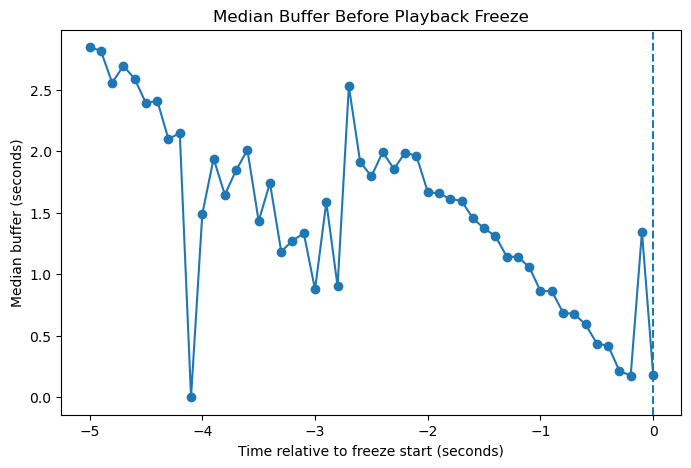

In [64]:
import matplotlib.pyplot as plt

plot_data = (
    buffer_before_freeze
    .assign(
        rounded_time=lambda df:
        df["seconds_before_freeze"].round(1)
    )
    .groupby(
        "rounded_time",
        observed=True
    )["buffer"]
    .median()
    .reset_index()
    .sort_values("rounded_time")
)

plt.figure(figsize=(8, 5))

plt.plot(
    -plot_data["rounded_time"],
    plot_data["buffer"],
    marker="o"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.xlabel("Time relative to freeze start (seconds)")
plt.ylabel("Median buffer (seconds)")
plt.title("Median Buffer Before Playback Freeze")

plt.show()

In [65]:
episode_buffer_change = (
    buffer_before_freeze
    .sort_values(
        ["session_id", "index", "episode_id", "buffer_time"]
    )
    .groupby(
        ["session_id", "index", "episode_id"]
    )
    .agg(
        first_buffer=("buffer", "first"),
        last_buffer=("buffer", "last"),
        minimum_buffer=("buffer", "min"),
        observations=("buffer", "size")
    )
    .reset_index()
)

episode_buffer_change["buffer_change"] = (
    episode_buffer_change["last_buffer"]
    - episode_buffer_change["first_buffer"]
)

episode_buffer_change["buffer_declined"] = (
    episode_buffer_change["buffer_change"] < 0
)

print("Matched episodes:", len(episode_buffer_change))

print(
    "Episodes with declining buffer:",
    episode_buffer_change["buffer_declined"].sum()
)

print(
    "Percentage with declining buffer:",
    episode_buffer_change["buffer_declined"].mean() * 100
)

Matched episodes: 5541
Episodes with declining buffer: 2954
Percentage with declining buffer: 53.31167659267281


Question → table → key → time window → metric

Among 5,541 playback-freeze episodes, 53.31% showed a net decline in buffer during the five seconds before the freeze began.

In [67]:
episode_risk_groups = episode_buffer_change.copy()

episode_risk_groups["low_buffer_1s"] = (
    episode_risk_groups["minimum_buffer"] < 1.0
)

episode_risk_groups["low_buffer_05s"] = (
    episode_risk_groups["minimum_buffer"] < 0.5
)

episode_risk_groups["buffer_zero"] = (
    episode_risk_groups["minimum_buffer"] <= 0
)

total_episodes = len(episode_risk_groups)

low_buffer_summary = pd.DataFrame({
    "metric": [
        "Total freeze episodes",
        "Episodes below 1 second",
        "Episodes below 0.5 seconds",
        "Episodes reaching zero"
    ],
    "episodes": [
        total_episodes,
        episode_risk_groups["low_buffer_1s"].sum(),
        episode_risk_groups["low_buffer_05s"].sum(),
        episode_risk_groups["buffer_zero"].sum()
    ]
})

low_buffer_summary["percentage"] = (
    low_buffer_summary["episodes"]
    / total_episodes
    * 100
)

display(low_buffer_summary)

,metric,episodes,percentage
0,Total freeze episodes,5541,100.000000
1,Episodes below 1 second,5456,98.465981
2,Episodes below 0.5 seconds,5392,97.310955
3,Episodes reaching zero,4277,77.188233


Low buffer is an almost universal precursor to playback freezing. Among 5,541 freeze episodes, 98.47% reached a buffer level below one second during the preceding five seconds, while 77.19% reached zero.